<h2 align="center">Website Traffic Analysis</h2>

## Objective

The objective of this project is to analyze website interaction data to understand user engagement patterns across different events, countries, cities, artists, albums, and tracks. The analysis focuses on identifying user activity trends, popular content, and geographic distribution to generate actionable business insights that can help Alfido Tech improve user engagement and optimize marketing strategies. The project includes data cleaning, exploratory data analysis (EDA), visualization, and business recommendations based on the available event-level interaction data.

<h3>Importing Libraries</h3>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df=pd.read_csv("traffic.csv")

<h3>Dataset Overview</h3>

In [3]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:

df.shape

(226278, 9)

In [5]:

df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [7]:
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


<h3>Data Cleaning</h3>

In [8]:
#checking null values
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [9]:
#checking for duplicates
df.duplicated().sum()

103711

In [10]:
#dropping duplicates
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df.isnull().sum()

event         0
date          0
country       5
city          5
artist       28
album         4
track         4
isrc       6306
linkid        0
dtype: int64

<h3>Replacing null values</h3>

In [13]:
df['country'] = df['country'].fillna('Unknown')

In [14]:
df['city'] = df['city'].fillna('Unknown')

In [15]:
df['artist'] = df['artist'].fillna('Unknown Artist')

In [16]:
df['album'] = df['album'].fillna('Unknown Album')

In [17]:
df['track'] = df['track'].fillna('Unknown Track')

In [18]:
df['isrc'] = df['isrc'].fillna('Unknown')

In [19]:
df.isnull().sum()

event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64

In [20]:
df.duplicated().sum()

0

In [21]:
#date conversion
df['date']=pd.to_datetime(df['date'])

<h3>Feature Engineering</h3>

In [22]:
df['Month']=df['date'].dt.month_name()

In [23]:
df['Year']=df['date'].dt.year

In [24]:
df['Day']=df['date'].dt.day_name()

<h3>KPI Analysis</h3>

In [25]:
#Total Events
print("Total Events:",len(df))

Total Events: 122567


In [26]:
#Total Unique Links
print("Unique Links:",df['linkid'].nunique())

Unique Links: 3839


In [27]:
#Total Countries
print("Countries:",df['country'].nunique())

Countries: 212


In [28]:
#Total Cities
print("Cities:",df['city'].nunique())

Cities: 11993


In [29]:
#Event Distribution
print(df['event'].value_counts())

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


<h3>Visualization</h3>

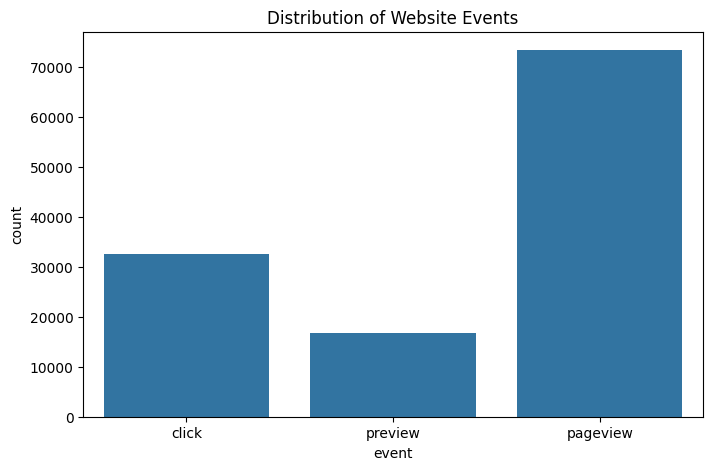

In [30]:
#Event Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df,x='event')

plt.title("Distribution of Website Events")

plt.savefig("events.png",dpi=300,bbox_inches="tight")

plt.show()

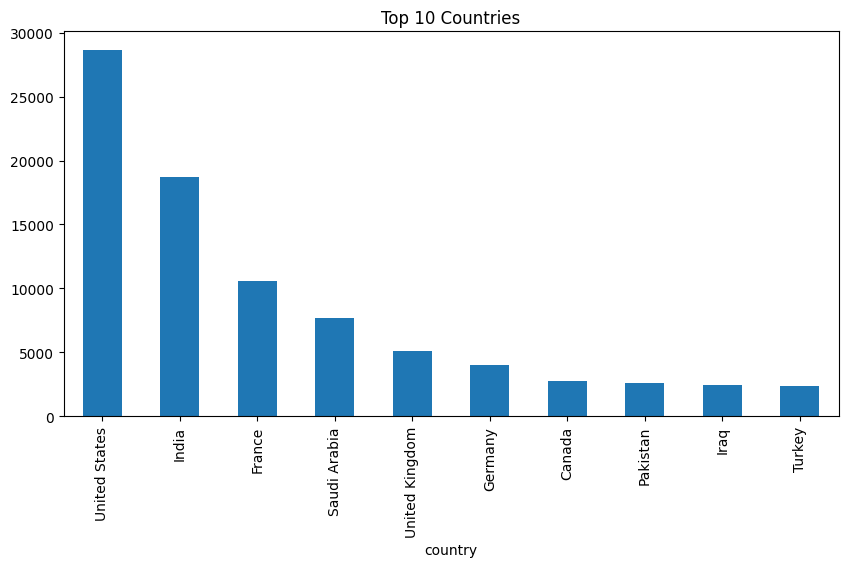

In [31]:
#Top Countries

top_country=df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_country.plot(kind='bar')

plt.title("Top 10 Countries")

plt.savefig("country.png",dpi=300,bbox_inches="tight")

plt.show()

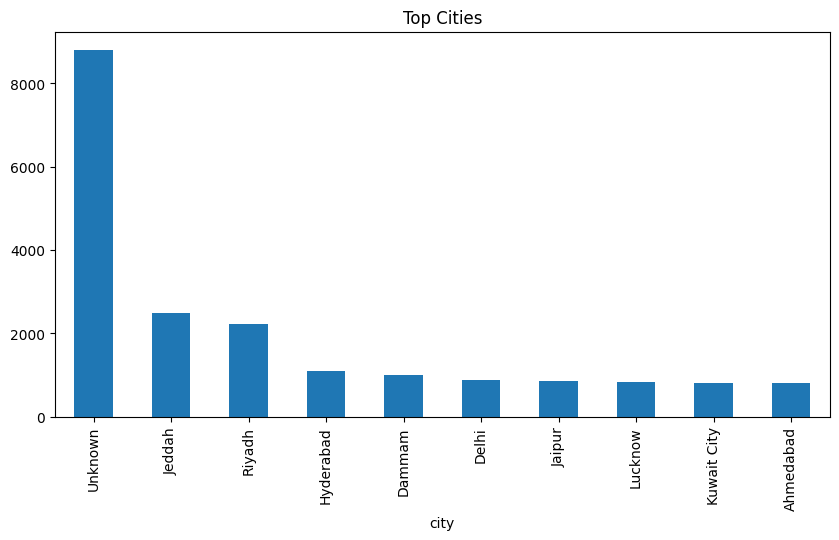

In [32]:
#Top Cities

top_city=df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_city.plot(kind='bar')

plt.title("Top Cities")

plt.savefig("cities.png",dpi=300,bbox_inches="tight")

plt.show()

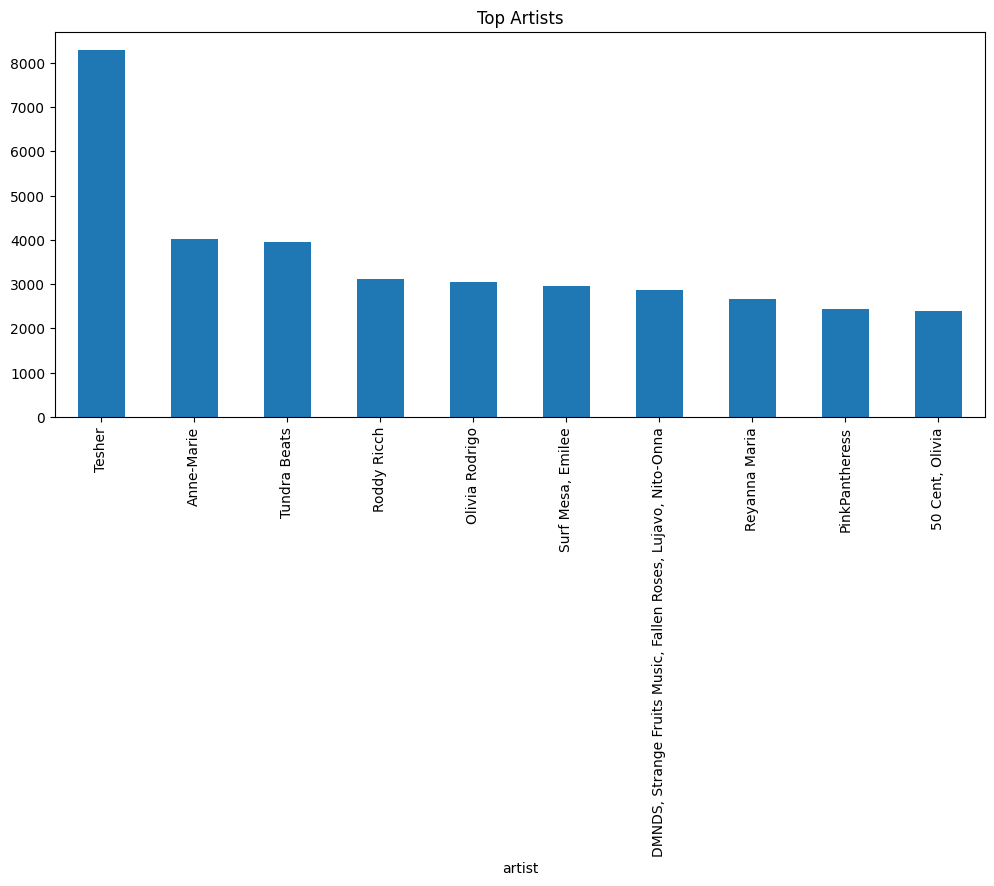

In [33]:
#Top Artists

artist=df['artist'].value_counts().head(10)

plt.figure(figsize=(12,5))

artist.plot(kind='bar')

plt.title("Top Artists")

plt.savefig("artists.png",dpi=300,bbox_inches="tight")

plt.show()

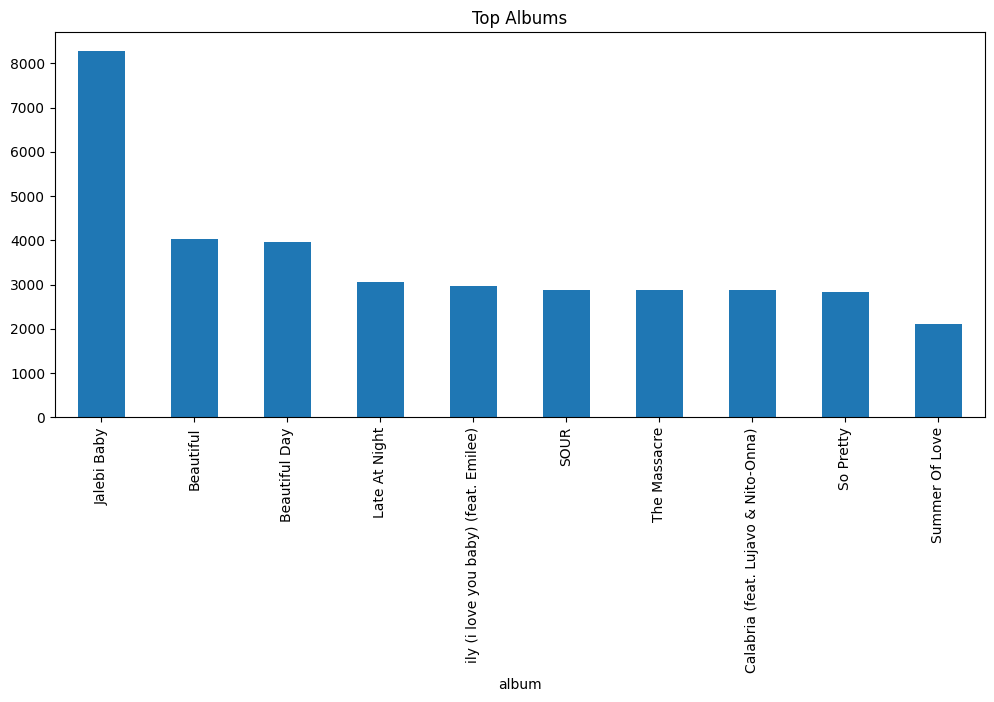

In [34]:
#Top Albums

album=df['album'].value_counts().head(10)

plt.figure(figsize=(12,5))

album.plot(kind='bar')

plt.title("Top Albums")

plt.savefig("albums.png",dpi=300,bbox_inches="tight")

plt.show()

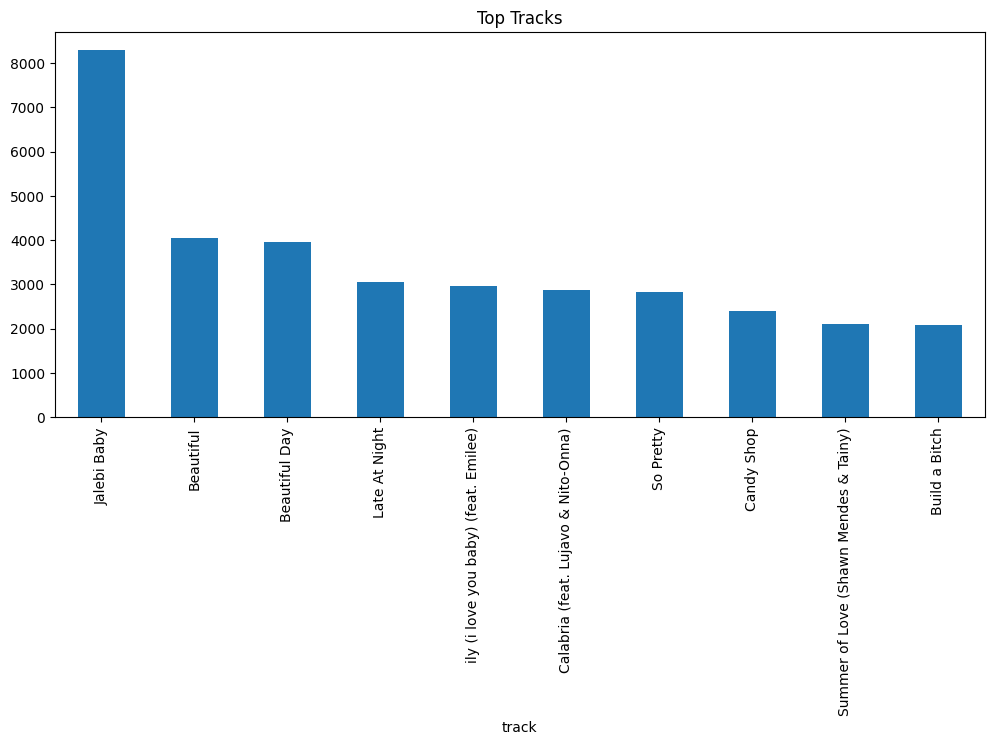

In [35]:
#Top Tracks

track=df['track'].value_counts().head(10)

plt.figure(figsize=(12,5))

track.plot(kind='bar')

plt.title("Top Tracks")

plt.savefig("tracks.png",dpi=300,bbox_inches="tight")

plt.show()

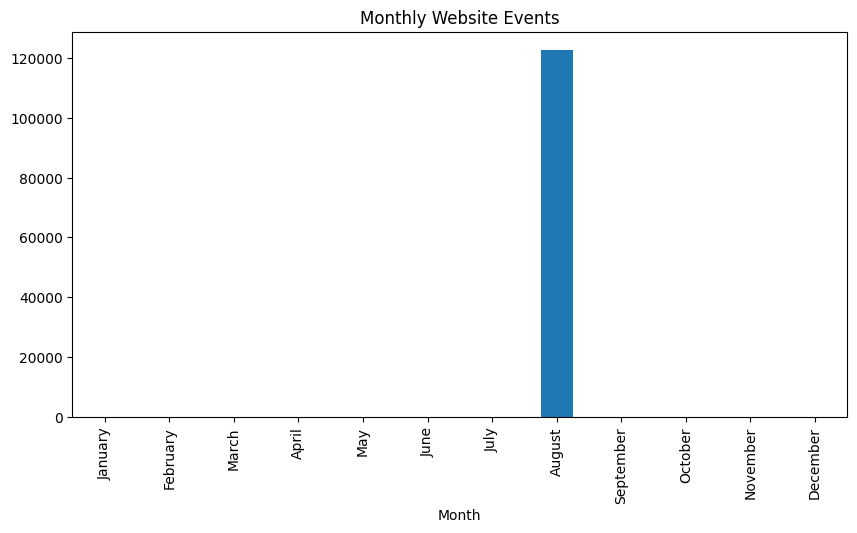

In [36]:
#Monthly Traffic

monthly=df.groupby('Month')['event'].count()

months=[
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly=monthly.reindex(months)

plt.figure(figsize=(10,5))

monthly.plot(kind='bar')

plt.title("Monthly Website Events")

plt.savefig("monthly.png",dpi=300,bbox_inches="tight")

plt.show()

In [37]:
#Country Wise Event Type
pd.crosstab(df['country'],df['event']).head(10)

event,click,pageview,preview
country,,,
Afghanistan,0,2,0
Albania,58,231,58
Algeria,96,328,91
American Samoa,1,3,0
Andorra,0,2,1
Angola,21,40,9
Anguilla,1,4,0
Antigua and Barbuda,1,4,0
Argentina,14,55,14


<Axes: xlabel='country'>

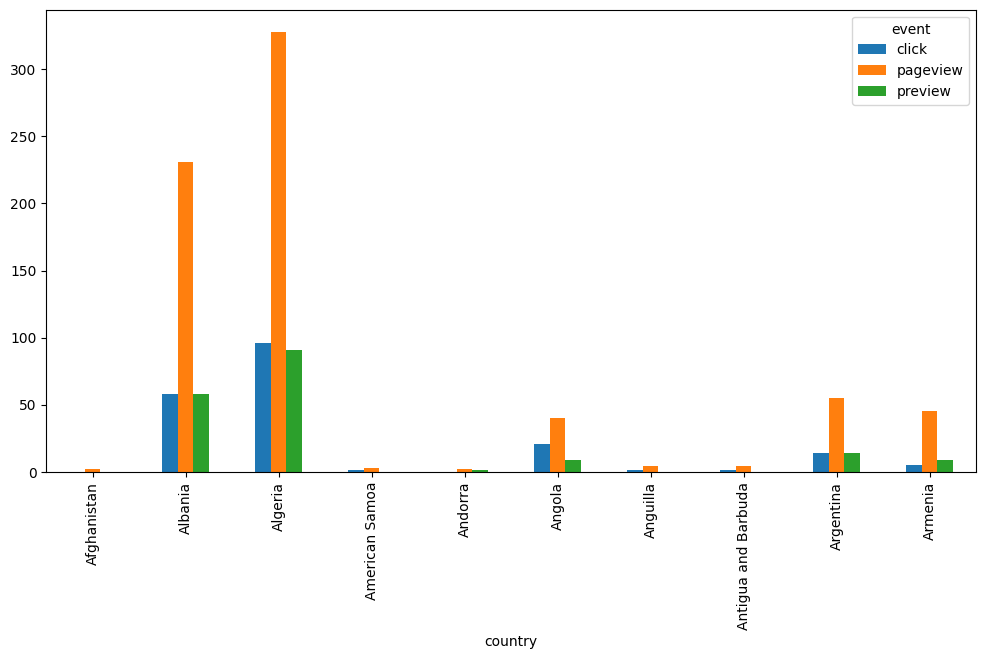

In [38]:
#visualization-country Wise Event Type

country_event=pd.crosstab(df['country'],df['event'])

country_event.head(10).plot(kind='bar',figsize=(12,6))

In [39]:
print("Key Insights\n")

print("1. Click events account for the majority of recorded website interactions.")

print("2. Traffic is concentrated in a small number of countries and cities.")

print("3. Certain artists, albums, and tracks receive significantly more user engagement than others.")

print("4. Website activity remains relatively consistent over the available time period.")

print("5. A small number of unique links generate most user interactions.")

print("6. Geographic analysis helps identify high-engagement markets for targeted campaigns.")

Key Insights

1. Click events account for the majority of recorded website interactions.
2. Traffic is concentrated in a small number of countries and cities.
3. Certain artists, albums, and tracks receive significantly more user engagement than others.
4. Website activity remains relatively consistent over the available time period.
5. A small number of unique links generate most user interactions.
6. Geographic analysis helps identify high-engagement markets for targeted campaigns.


In [40]:
print("Recommendations\n")

print("1. Focus marketing campaigns on high-traffic countries and cities.")

print("2. Promote the most popular artists and tracks to maximize engagement.")

print("3. Optimize underperforming links to improve click-through rates.")

print("4. Analyze successful links and replicate their content strategy.")

print("5. Expand promotional efforts in regions showing growing user activity.")

Recommendations

1. Focus marketing campaigns on high-traffic countries and cities.
2. Promote the most popular artists and tracks to maximize engagement.
3. Optimize underperforming links to improve click-through rates.
4. Analyze successful links and replicate their content strategy.
5. Expand promotional efforts in regions showing growing user activity.


## Conclusion

This project analyzed website interaction data to gain insights into user engagement and content performance. The analysis identified the most common user events, top-performing countries, cities, artists, albums, and tracks, providing a better understanding of user behavior and geographic reach. These findings can help Alfido Tech focus marketing efforts on high-engagement regions, promote popular content, and improve overall user interaction.

It is important to note that the provided dataset does not include session identifiers, user identifiers, page URLs, or session duration. Therefore, metrics such as sessions, bounce rate, average session duration, landing pages, and exit pages could not be calculated. Despite these limitations, the event-level analysis provides meaningful insights that support data-driven business decisions and marketing optimization.